In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load CSV file

df = pd.read_csv("gapminder2007.csv")

# Display first rows

df.head()

,country,pop,continent,lifeExp,gdpPercap
0,Afghanistan,31889923.0,Asia,43.828,974.580338
1,Albania,3600523.0,Europe,76.423,5937.029526
2,Algeria,33333216.0,Africa,72.301,6223.367465
3,Angola,12420476.0,Africa,42.731,4797.231267
4,Argentina,40301927.0,Americas,75.320,12779.379640


In [3]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    142 non-null    str    
 1   pop        142 non-null    float64
 2   continent  142 non-null    str    
 3   lifeExp    142 non-null    float64
 4   gdpPercap  142 non-null    float64
dtypes: float64(3), str(2)
memory usage: 7.7 KB


In [4]:
# Select numerical columns for clustering

features = [
    "lifeExp",
    "pop",
    "gdpPercap"
]

X = df[features]

X.head()

,lifeExp,pop,gdpPercap
0,43.828,31889923.0,974.580338
1,76.423,3600523.0,5937.029526
2,72.301,33333216.0,6223.367465
3,42.731,12420476.0,4797.231267
4,75.320,40301927.0,12779.379640


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.92673191, -0.08246934, -0.8354152 ],
       [ 0.78264648, -0.27478252, -0.44816484],
       [ 0.44001547, -0.07265774, -0.42582013],
       [-2.01791731, -0.2148239 , -0.53711029],
       [ 0.69096235, -0.02528399,  0.08578574]])

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.92673191, -0.08246934, -0.8354152 ],
       [ 0.78264648, -0.27478252, -0.44816484],
       [ 0.44001547, -0.07265774, -0.42582013],
       [-2.01791731, -0.2148239 , -0.53711029],
       [ 0.69096235, -0.02528399,  0.08578574]])

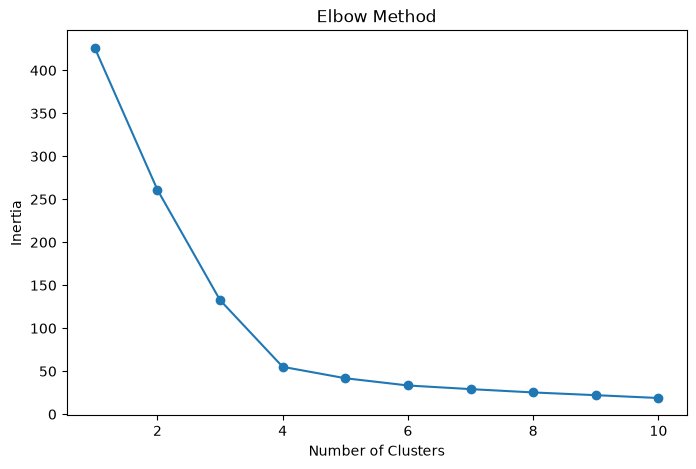

In [7]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [9]:
# Combine text information

df["text"] = (
    df["country"].astype(str)
    + " "
    + df["continent"].astype(str)
)


df[["country","continent","text"]].head()

,country,continent,text
0,Afghanistan,Asia,Afghanistan Asia
1,Albania,Europe,Albania Europe
2,Algeria,Africa,Algeria Africa
3,Angola,Africa,Angola Africa
4,Argentina,Americas,Argentina Americas


In [10]:
vectorizer = TfidfVectorizer(
    stop_words="english"
)


text_matrix = vectorizer.fit_transform(
    df["text"]
)


text_matrix.shape

(142, 166)

In [12]:
df.to_csv(
    "gapminder2007_kmeans_nlp_results.csv",
    index=False
)